# **01 Data Generation**

This notebook shows how to use pretrained models to generate realistic, conditioned FTIR spectra.

In [ ]:
# obligatory imports
import sys
sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import joblib
import torch
import numpy as np
import contextlib
import io
import random
import pandas as pd
from sklearn.manifold import TSNE

from models.cbegan_lightning import SpectralCBEGAN
from models.cvae_lightning import LitVAE
from models.cdiff_lightning import LitCfgDiffusion

from utils.utils import encode_labels
from utils.experiments import load_models, generate_batch_spectra

# Load data settings

In order to correctly use the trained models, we need to scale and encode new data according to our training procedure.

In [2]:
# Load data info, scalers and the categorical encoder
label_encoder = joblib.load("../pretrained_models/scalers/label_encoder.pkl")
minmax_scaler = joblib.load("../pretrained_models/scalers/minmax_scaler.pkl")
categorical_conditions = joblib.load("../pretrained_models/scalers/categorical_conditions.pkl")
continuous_conditions = joblib.load("../pretrained_models/scalers/continuous_conditions.pkl")
standard_scaler = joblib.load("../pretrained_models/scalers/std_scaler.pkl")

c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
def generate_spectra(model, conditions, num_samples=1, device=None, column_names=None):
    """
    Wrapper around generate_batch_spectra that accepts raw/unscaled conditions.
    """
    sex_map = {"male": 0, "female": 1}

    # Normalize to DataFrame
    if isinstance(conditions, pd.Series):
        conditions = conditions.to_frame().T.reset_index(drop=True)

    labels = pd.concat([conditions] * num_samples, ignore_index=True)

    # Encode sex
    labels["sex"] = labels["sex"].map(sex_map)

    # Scale bmi (col 0) and age (col 1)
    labels[["age", "bmi"]] = minmax_scaler.transform(labels[["age", "bmi"]])

    return generate_batch_spectra(model=model, labels=labels, device=device, column_names=column_names)

# Load pretrained models

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = load_models()

cbegan = models["CBEGAN"]
cvae = models["CVAE"]
cdiff = models["CDIFF"]

# Generate FTIR spectra

Lets start by creating a sample condition dict, representing a subject.

In [5]:
condition = pd.Series({
    "sex": 'male',
    "bmi": 25,
    "age": 38
})

And define some helper functions, to encode conditions and to predict new spectra.

Then we can predict:

In [6]:
spectrum_cbegan_scaled = generate_spectra(cbegan, condition).values
spectrum_cvae_scaled = generate_spectra(cvae, condition).values
spectrum_cdiff_scaled = generate_spectra(cdiff, condition).values

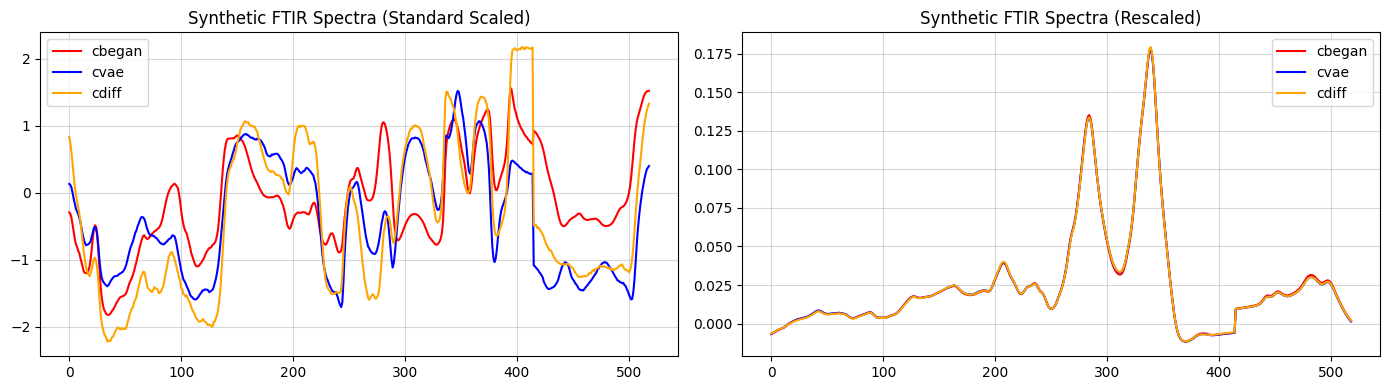

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left: standard scaled ---
axes[0].set_title("Synthetic FTIR Spectra (Standard Scaled)")
axes[0].plot(spectrum_cbegan_scaled[0], color="red",    label="cbegan")
axes[0].plot(spectrum_cvae_scaled[0],   color="blue",   label="cvae")
axes[0].plot(spectrum_cdiff_scaled[0],  color="orange", label="cdiff")
axes[0].grid(alpha=0.5)
axes[0].legend()

# --- Right: inverse transformed ---
spectrum_cbegan = standard_scaler.inverse_transform(spectrum_cbegan_scaled[0].reshape(1, -1))
spectrum_cvae   = standard_scaler.inverse_transform(spectrum_cvae_scaled[0].reshape(1, -1))
spectrum_cdiff  = standard_scaler.inverse_transform(spectrum_cdiff_scaled[0].reshape(1, -1))

axes[1].set_title("Synthetic FTIR Spectra (Rescaled)")
axes[1].plot(spectrum_cbegan[0], color="red",    label="cbegan")
axes[1].plot(spectrum_cvae[0],   color="blue",   label="cvae")
axes[1].plot(spectrum_cdiff[0],  color="orange", label="cdiff")
axes[1].grid(alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()